# Encodage des variables 

Etant donné que l'on souhaite faire de la tarification, il serait plus adéquat de discrétiser les variables continues, avant de pouvoir classifier de façon compréhensible le risque représenté par un assuré.

In [1]:
R.version.string

[1] "R version 4.5.0 (2025-04-11 ucrt)"

In [88]:
install.packages("pscl", quiet = TRUE)
install.packages("ggplot2", quiet = TRUE, keep_outputs = FALSE)
install.packages("openxlsx", quiet = TRUE, keep_outputs = FALSE)

Warning message:
"le package 'pscl' est en cours d'utilisation et ne sera pas installé"
Warning message:
"le package 'ggplot2' est en cours d'utilisation et ne sera pas installé"
installation des dépendances 'Rcpp', 'stringi', 'zip'




le package 'Rcpp' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'stringi' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'zip' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'openxlsx' a été décompressé et les sommes MD5 ont été vérifiées avec succés


In [89]:
# Packages
library(stats) 
library(pscl, quietly = TRUE)
library(ggplot2, quietly = TRUE)
library(openxlsx, quietly = TRUE)

Warning message:
"le package 'openxlsx' a été compilé avec la version R 4.5.2"


In [6]:
# Charger les données 
home <- read.csv("data/home_data_cleaned.csv")
home <- home[,-1]
str(home)

'data.frame':	348262 obs. of  40 variables:
 $ client_id                : int  1 2 3 4 5 6 7 8 9 10 ...
 $ client_start_year        : int  2019 2013 2014 2017 2020 2018 2016 2013 2023 2014 ...
 $ oldest_insured_year_birth: int  1988 1941 1992 1991 1989 1953 1973 1989 1974 1946 ...
 $ insured_employment       : chr  "Healthcare" "Unemployed" "Other" "Other" ...
 $ credit_score             : int  687 543 778 699 388 796 808 798 826 972 ...
 $ marital_status           : chr  "Married" "Divorced" "Married" "Married" ...
 $ num_children             : int  1 3 2 1 2 2 1 4 4 4 ...
 $ smoker                   : chr  "No" "No" "No" "Yes" ...
 $ past_claims              : int  0 0 0 0 0 0 0 0 0 0 ...
 $ region                   : chr  "Estrie" "Laval" "Quebec City" "Outaouais" ...
 $ construction_year        : num  1934 2012 1996 1940 1981 ...
 $ house_type               : chr  "Semi-detached" "Detached" "Detached" "Semi-detached" ...
 $ reconstruction_cost      : int  915000 170000 345000 20000

## Client_start_year

[1] 2023

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   4.000   7.000   6.728   9.000  14.000 

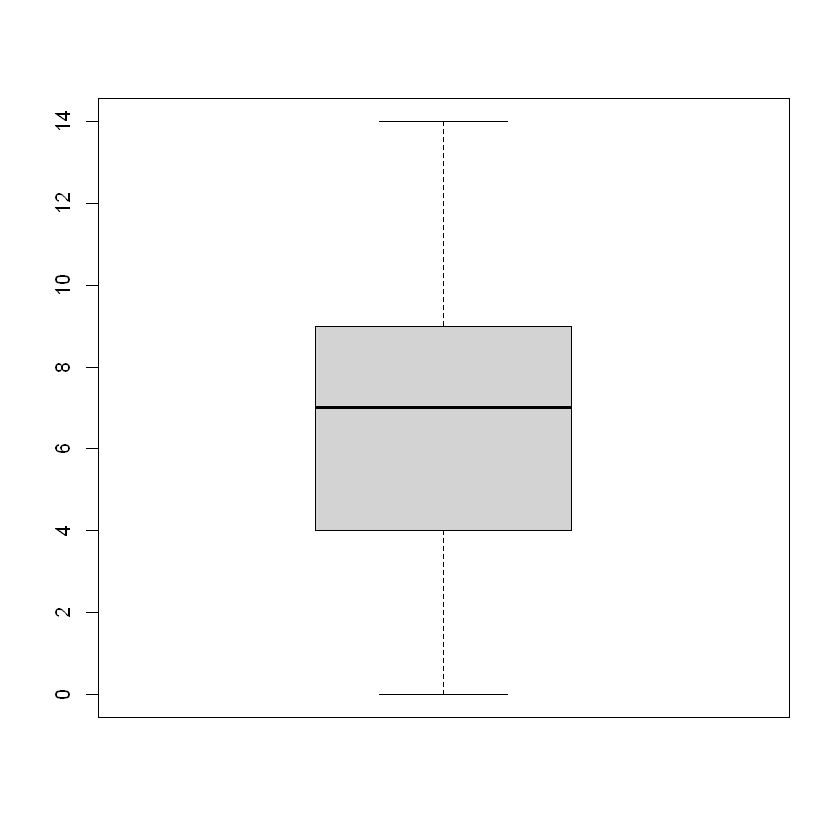

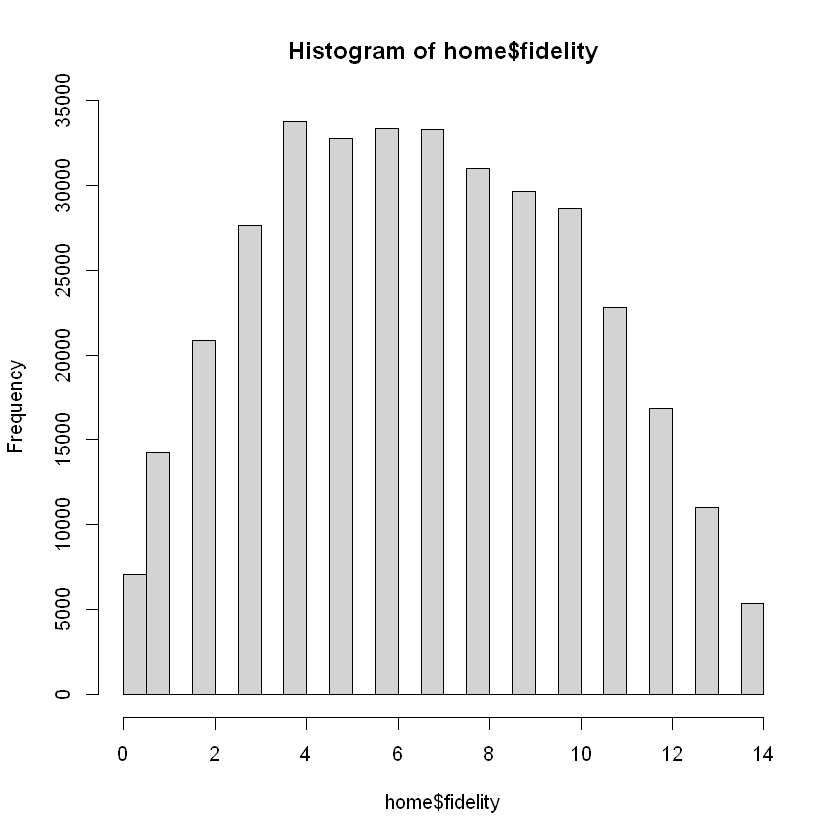

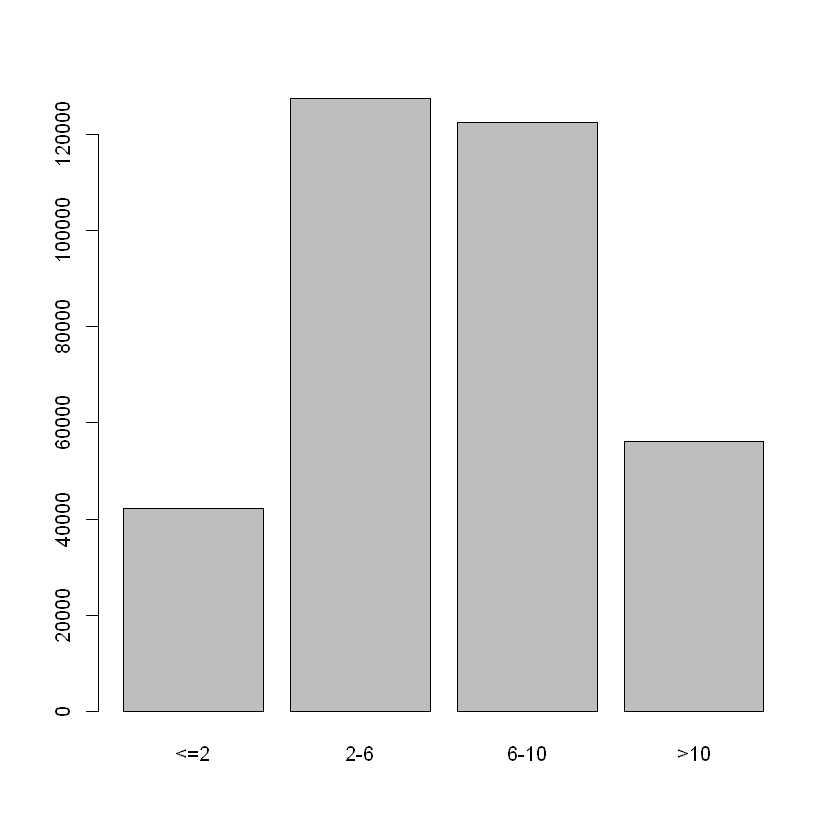

In [10]:
max(home$client_start_year)
home$fidelity <- 2023 - home$client_start_year
summary(home$fidelity)
par(bg = "white")
boxplot(home$fidelity)

par(bg = "white")
hist(home$fidelity)

home$fidelity_cat <- cut(home$fidelity,
                         breaks = c(-Inf, 2,
                                    6, 10, Inf),
                         labels = c("<=2", "2-6", 
                                    "6-10", ">10"))

par(bg = "white")
barplot(table(home$fidelity_cat))

## Age of the oldest insured

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  18.00   38.00   56.00   56.02   74.00   94.00 

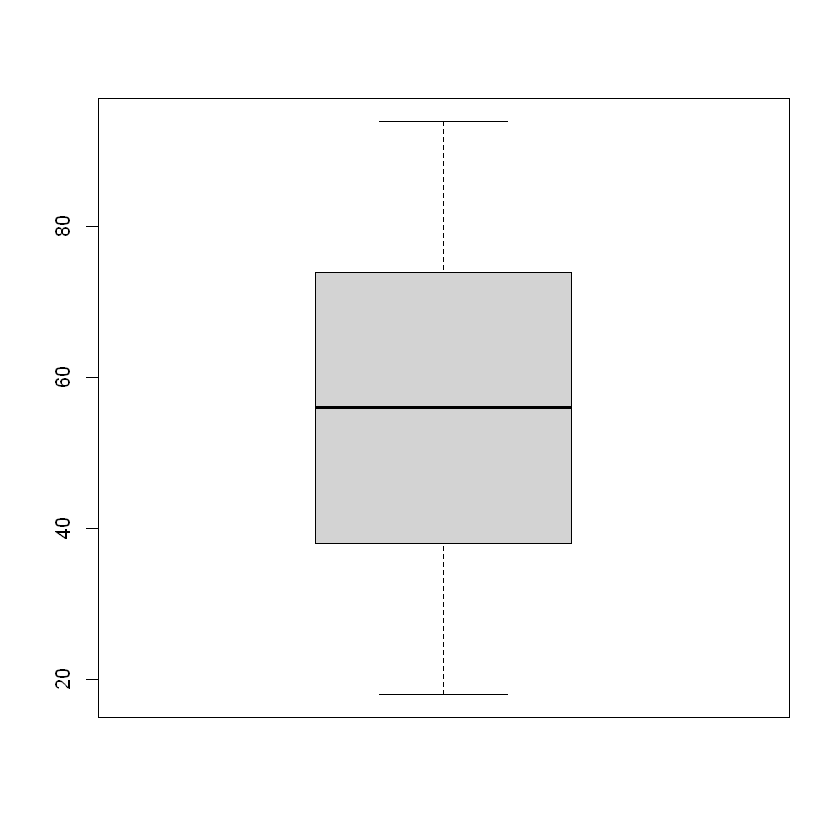

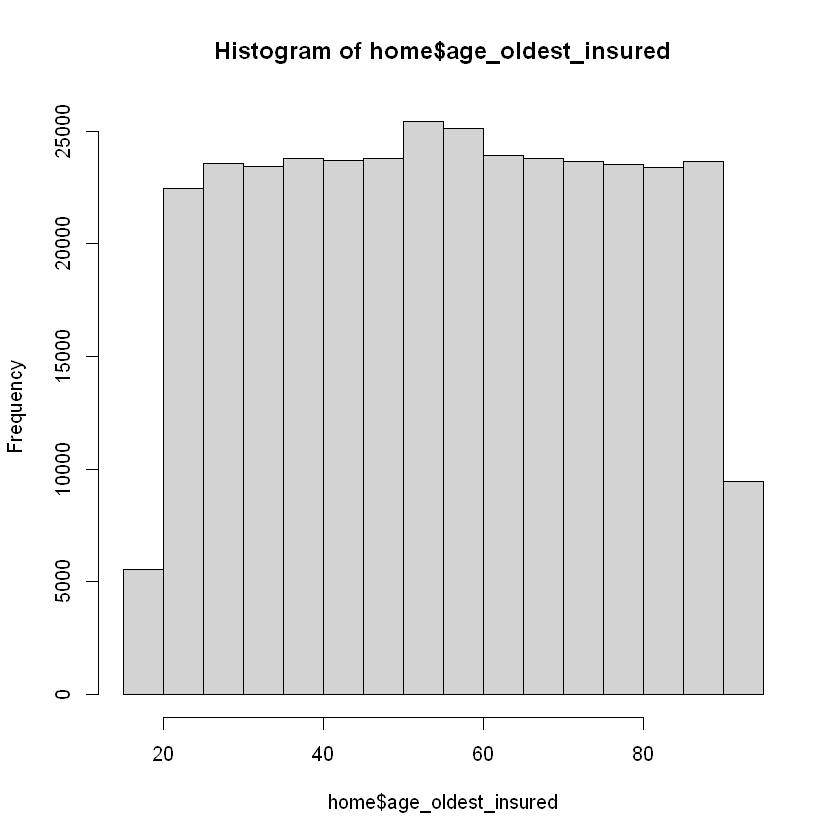

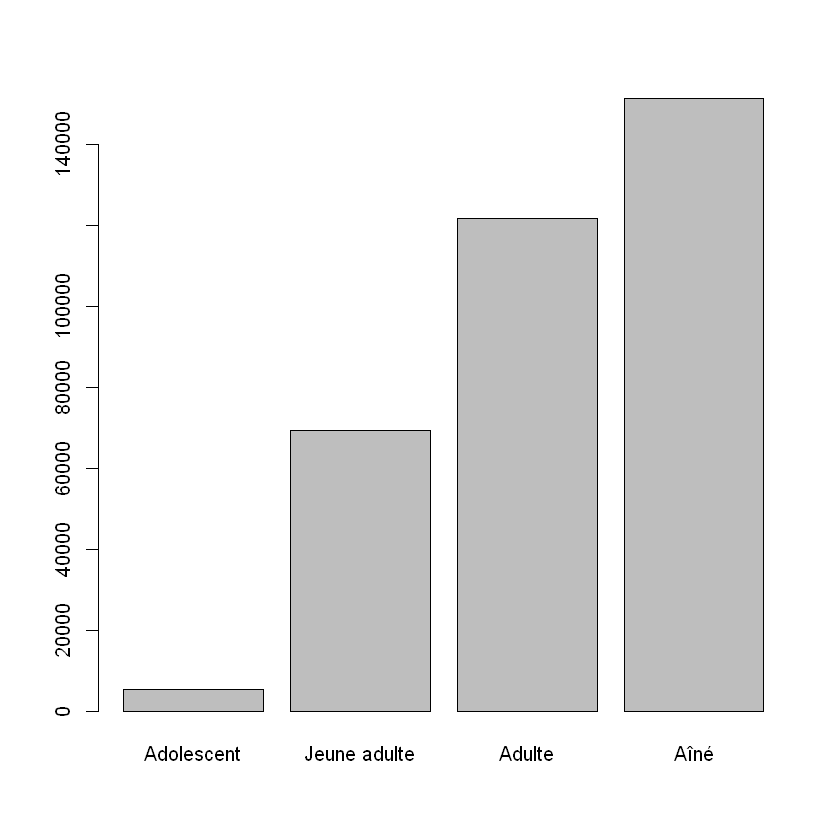

In [11]:
home$age_oldest_insured <- 2023 - home$oldest_insured_year_birth
summary(home$age_oldest_insured)

par(bg = "white")
boxplot(home$age_oldest_insured)

par(bg = "white")
hist(home$age_oldest_insured)

home$group_age_oldest_insured <- cut(home$age_oldest_insured,
                                     breaks = c(0, 20, 35, 60, Inf),
                                     labels = c("Adolescent",
                                                "Jeune adulte",
                                                "Adulte",
                                                "Aîné"))

par(bg = "white")
barplot(table(home$group_age_oldest_insured))

## Côte de crédit (selon TransUnion)

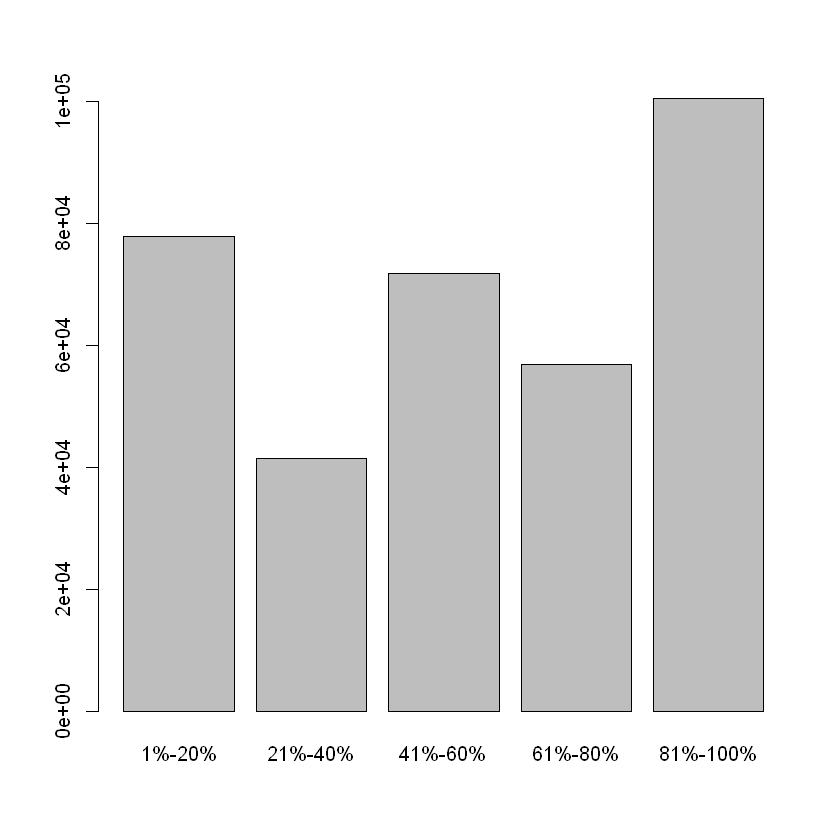

In [12]:
home$credit_score_level <- cut(home$credit_score,
                               breaks = c(0, 692, 742, 789, 832, Inf),
                               labels = c("1%-20%", "21%-40%",
                                          "41%-60%", "61%-80%",
                                          "81%-100%"))
par(bg="white")
barplot(table(home$credit_score_level))

## Past claims 

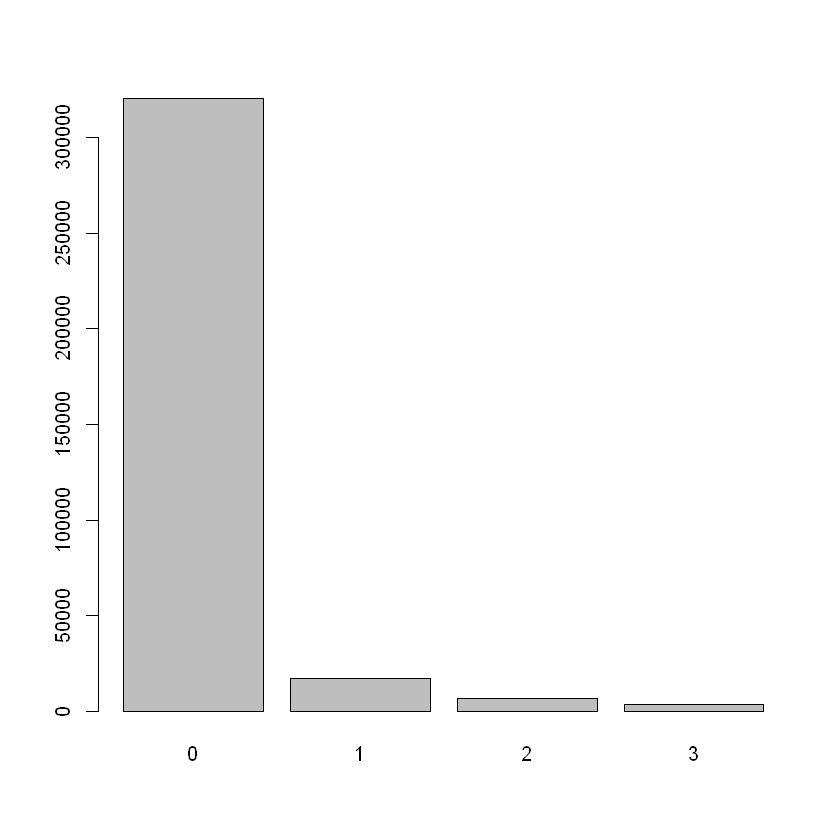

In [13]:
home$past_claims <- as.factor(home$past_claims)
par(bg="white")
barplot(table(home$past_claims))

## Floors above ground 

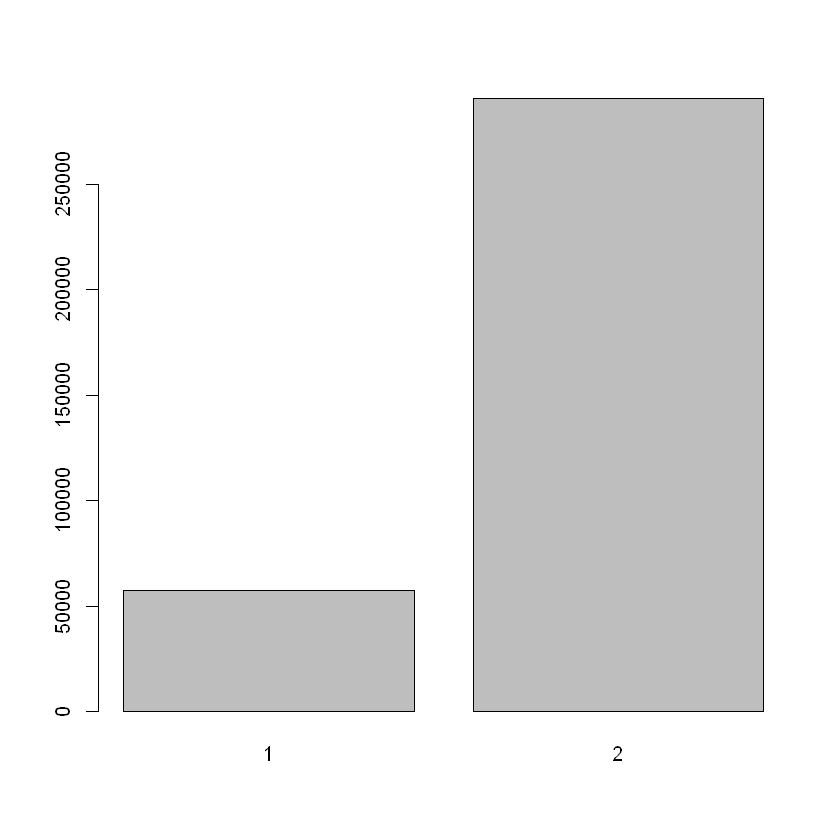

In [14]:
home$floors_above_ground <- as.factor(home$floors_above_ground)
par(bg="white")
barplot(table(home$floors_above_ground))

## Num children 

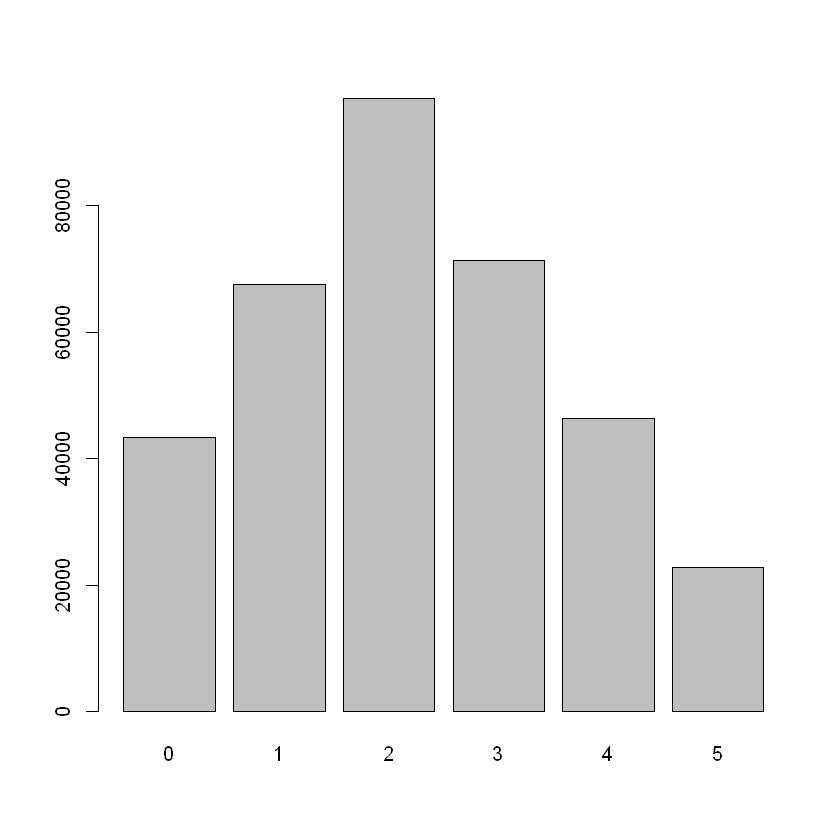

In [16]:
par(bg="white")
barplot(table(home$num_children))
home$num_children <- as.factor(home$num_children)

## Construction year 

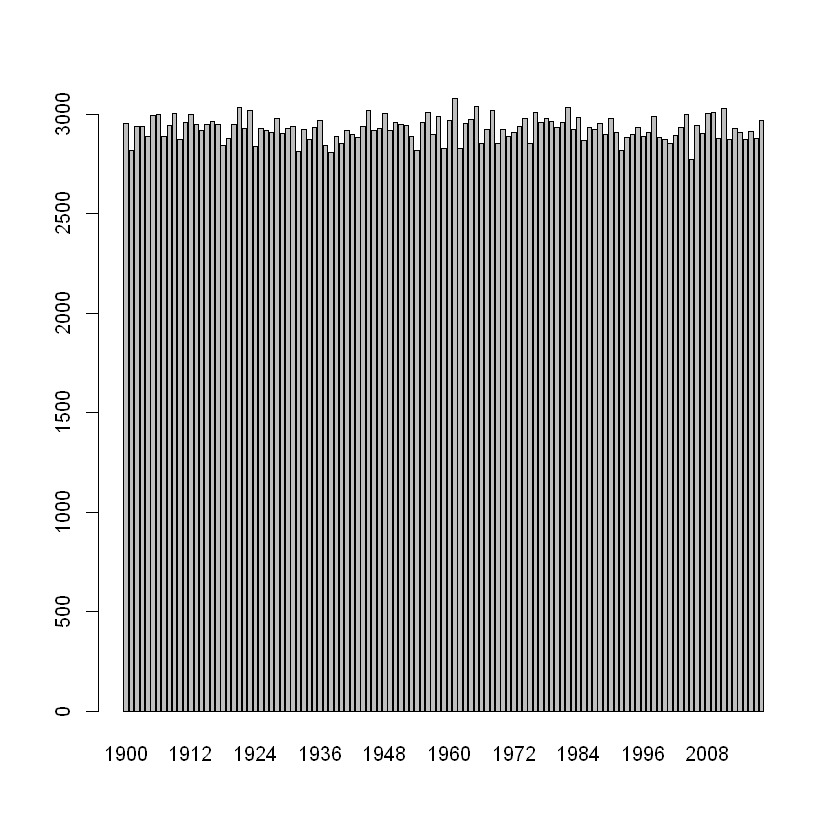

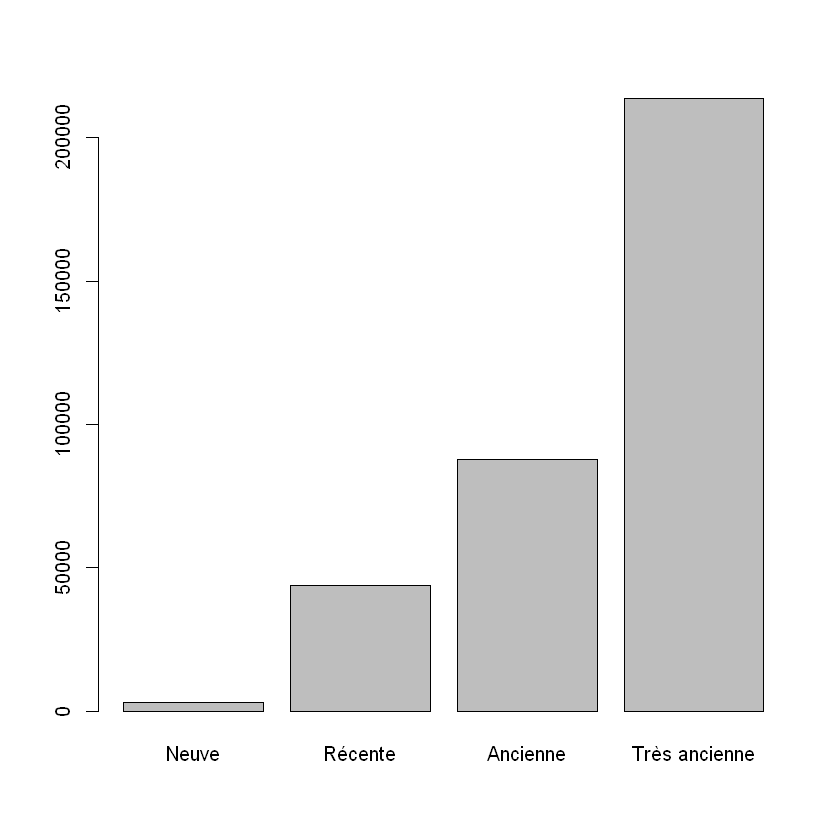

In [17]:
par(bg="white")
barplot(table(home$construction_year))

home$age_maison <- 2023 - home$construction_year

home$etat_maison <- cut(home$age_maison,
                        breaks = c(-Inf, 5, 20, 50, Inf),
                        labels = c("Neuve",
                                   "Récente",
                                   "Ancienne",
                                   "Très ancienne"),
                        right = TRUE)

par(bg="white")
barplot(table(home$etat_maison))

## Roof year 

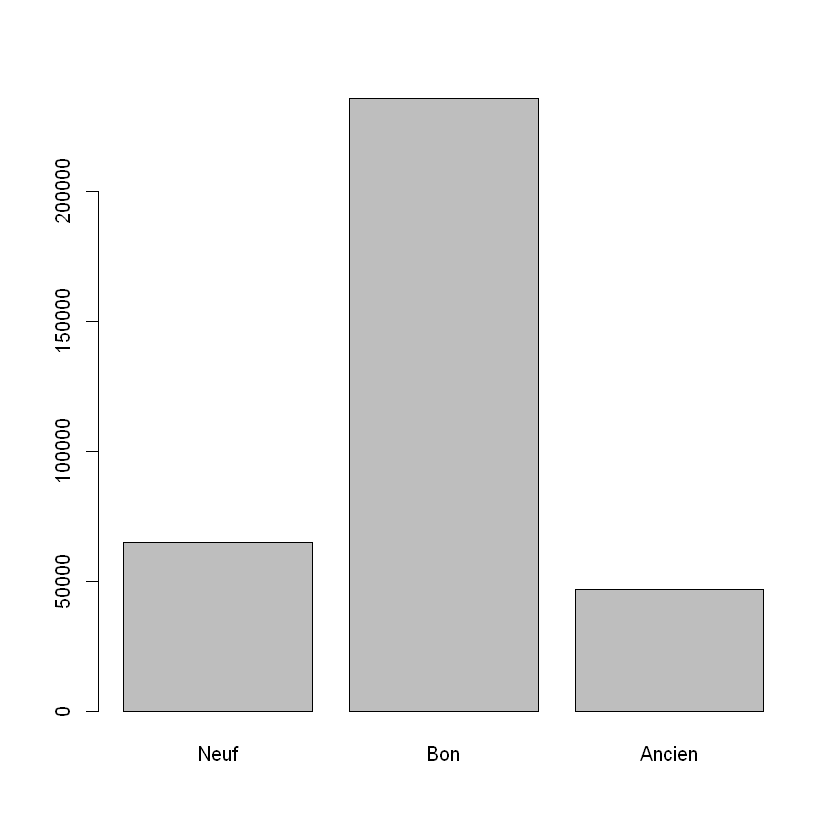

In [18]:
home$age_roof <- 2023 - home$roof_year

home$etat_toit <- cut(home$age_roof,
                      breaks = c(-Inf, 5, 15, Inf),
                      labels = c("Neuf",
                                 "Bon",
                                 "Ancien"),
                      right = TRUE)

par(bg="white")
barplot(table(home$etat_toit))

## Residence stability 

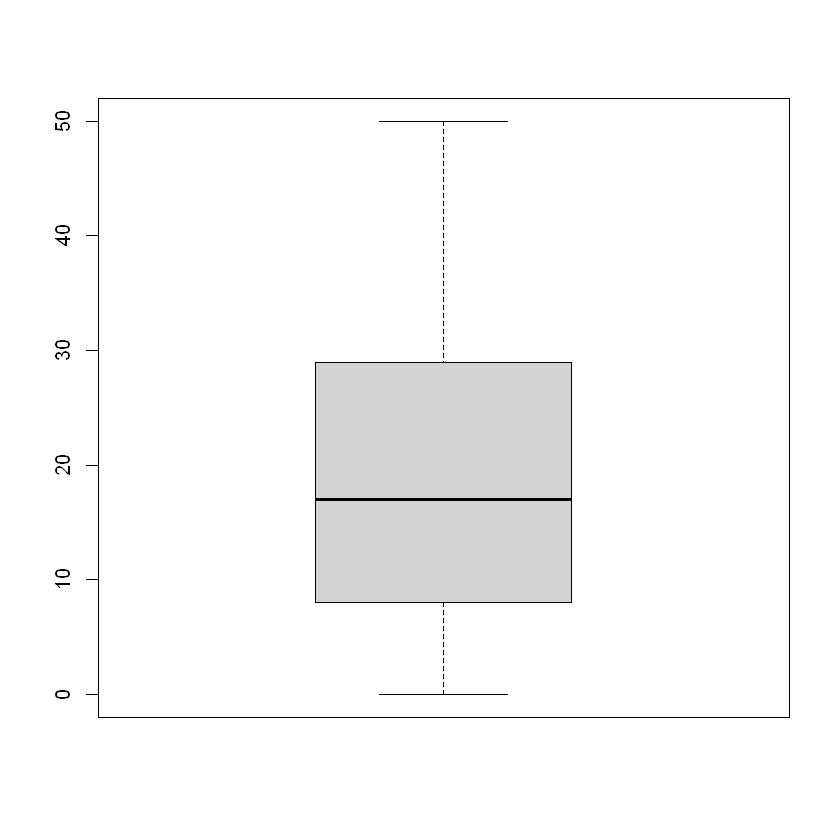

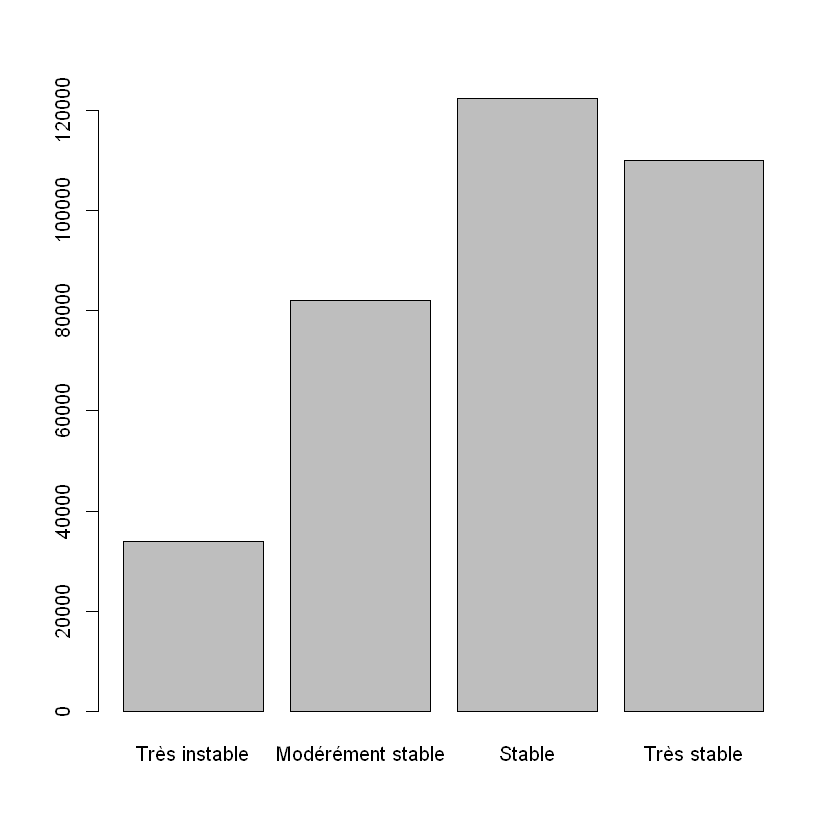

In [19]:
par(bg="white")
boxplot(home$residence_stability)

home$residence_stability_group <- cut(home$residence_stability,
                                      breaks = c(-Inf, 2, 10, 25, Inf),
                                      labels = c("Très instable",
                                                 "Modérément stable",
                                                 "Stable",
                                                 "Très stable"),
                                      right = TRUE)

par(bg="white")
barplot(table(home$residence_stability_group))

## Deductible 

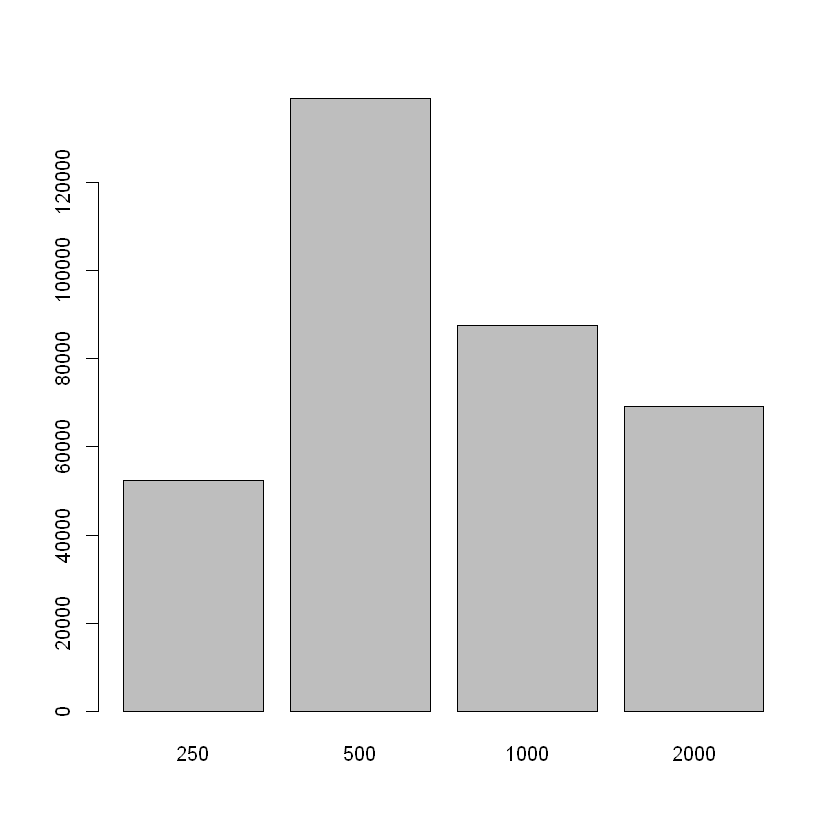

In [20]:
home$deductible <- as.factor(home$deductible)
par(bg="white")
barplot(table(home$deductible))

# Modèle de fréquence 

## Modèle de Poisson 

A partir des variables du jeu de données, on tente de modéliser la fréquence des accidents en assurance habitation en utilisant la méthode forward.

In [21]:
# Modèle de base 
mod0 <- glm(num_claims ~ 1,
            data = home,
            family = poisson(link = "log"),
            offset = log(earned_exposure))

# Modèle complet 
mod_complet <- glm(num_claims ~ insured_employment + marital_status + num_children + smoker + past_claims + region 
            + house_type + floors_above_ground + exterior_cladding +
                heating_type + auxiliary_heating + alarm_system +
                garage_type + basement + roof_type + skylight_presence
            + pool_presence + water_body_proximity + fire_station_proximity
            + hydrant_proximity + room_rental + commercial_activities
            + mortgage + liability_limit + deductible + earthquake_coverage
            + multi_product_discount + fidelity_cat + group_age_oldest_insured
            + credit_score_level + etat_maison + etat_toit
            + residence_stability_group,
            data = home,
            family = poisson(link = "log"),
            offset = log(earned_exposure))


# Sélection des variables par méthode forward 
mod_forward <- step(mod0,
                    scope = formula(mod_complet),
                    direction = "forward",
                    trace = TRUE)

Start:  AIC=110709
num_claims ~ 1

                            Df Deviance    AIC
+ exterior_cladding          2    84058 109044
+ roof_type                  2    84058 109044
+ garage_type                1    84063 109047
+ basement                   1    84063 109047
+ residence_stability_group  3    84582 109570
+ pool_presence              1    84734 109718
+ insured_employment         6    85190 110184
+ deductible                 3    85204 110192
+ group_age_oldest_insured   3    85254 110242
+ credit_score_level         4    85315 110305
+ region                    11    85337 110341
+ floors_above_ground        1    85388 110372
+ fidelity_cat               3    85409 110397
+ num_children               5    85438 110430
+ alarm_system               3    85452 110440
+ hydrant_proximity          1    85575 110559
+ heating_type               3    85573 110561
+ marital_status             3    85579 110567
+ fire_station_proximity     1    85622 110606
+ multi_product_discount 

In [26]:
frequence <- glm(num_claims ~ exterior_cladding + residence_stability_group + 
    deductible + region + alarm_system + hydrant_proximity + 
    fire_station_proximity + heating_type + fidelity_cat + insured_employment + 
    multi_product_discount + smoker + auxiliary_heating + etat_toit + 
    credit_score_level + past_claims + group_age_oldest_insured + 
    marital_status + house_type + water_body_proximity + skylight_presence + 
    room_rental + commercial_activities,
            data = home,
            family = poisson(link = "log"),
            offset = log(earned_exposure))

# sauvegarder le modèle
save(frequence, file = "data/modele_poisson_forward.RData")

In [25]:
# Résumé 
summary(frequence)


Call:
glm(formula = num_claims ~ exterior_cladding + residence_stability_group + 
    deductible + region + alarm_system + hydrant_proximity + 
    fire_station_proximity + heating_type + fidelity_cat + insured_employment + 
    multi_product_discount + smoker + auxiliary_heating + etat_toit + 
    credit_score_level + past_claims + group_age_oldest_insured + 
    marital_status + house_type + water_body_proximity + skylight_presence + 
    room_rental + commercial_activities, family = poisson(link = "log"), 
    data = home, offset = log(earned_exposure))

Coefficients:
                                           Estimate Std. Error z value Pr(>|z|)
(Intercept)                                -1.83425    0.71123  -2.579 0.009909
exterior_claddingVinyl                      0.26792    0.05248   5.105 3.30e-07
exterior_claddingWood                       0.73059    0.02057  35.517  < 2e-16
residence_stability_groupModérément stable -0.36590    0.02905 -12.597  < 2e-16
residence_stability_g

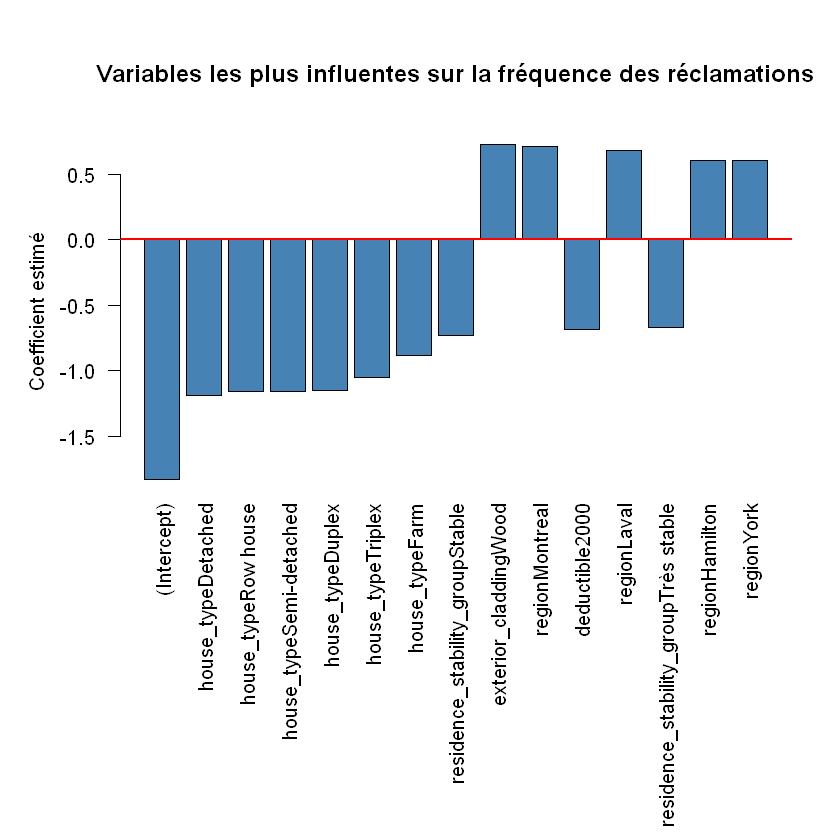

In [31]:
# Extraire les coefficients du modèle
coefs <- summary(frequence)$coefficients

# Trier selon la valeur absolue du coefficient
coefs_sorted <- coefs[order(abs(coefs[, "Estimate"]), decreasing = TRUE), ]

# Sélectionner les 15 variables les plus importantes
top_vars <- head(coefs_sorted, 15)

# Graphique
par(bg="white", mar=c(15, 5, 6, 2))
barplot(top_vars[, "Estimate"],
        names.arg = rownames(top_vars),
        las = 2, col = "steelblue",
        main = "Variables les plus influentes sur la fréquence des réclamations",
        ylab = "Coefficient estimé")
abline(h = 0, col = "red", lwd = 2)


Le graphique ci-dessus met en évidence les variables les plus influentes dans le modèle de Poisson expliquant la **fréquence des réclamations**.  

Les barres **positives** représentent les facteurs qui **augmentent le risque de sinistre**, tandis que les barres **négatives** indiquent ceux qui **le réduisent**.

On constate que certaines **caractéristiques du logement**, telles que le **revêtement en bois (`exterior_claddingWood`)** ou la localisation dans des **régions urbaines** comme **Montréal, Laval, Hamilton** ou **York**, sont associées à une **fréquence plus élevée de sinistres**.  
Ces effets positifs reflètent probablement une plus grande exposition aux risques matériels, climatiques ou comportementaux.

À l’inverse, des éléments comme le **type de maison** (`house_typeDetached`, `Row house`, `Semi-detached`, etc.) et une **forte stabilité résidentielle** (`residence_stability_groupStable`, `Très stable`) contribuent à **réduire la fréquence des réclamations**, traduisant des comportements d’assurés plus prudents ou une meilleure gestion du risque.

De même, les **franchises élevées** (`deductible2000`) diminuent le nombre de réclamations, car les assurés supportent davantage les petits sinistres.

En somme, ce graphique illustre que les **caractéristiques structurelles du logement**, la **stabilité du ménage** et le **niveau de franchise** jouent un rôle clé dans la gestion du risque, tandis que certaines **régions** et **matériaux de construction** amplifient la probabilité de sinistre.

In [34]:
# Dispersion du modèle
deviance(frequence) / df.residual(frequence) 

# Comparaison moyenne et variance 
c(mean(home$num_claims), var(home$num_claims))

# Proportion d'assuré sans réclamations
mean(home$num_claims == 0)

[1] 0.2312553

[1] 0.03689751 0.03855691

[1] 0.9645899

- **Dispersion du modèle :** Le rapport entre la déviance et les degrés de liberté vaut environ 0.23, soit nettement inférieur à 1.Cela indique une sous-dispersion, c’est-à-dire que la variance observée est inférieure à celle attendue sous un modèle de Poisson.
- **Moyenne vs variance :** La moyenne du nombre de sinistres est de 0.0369, et la variance de 0.0386. Ces deux valeurs sont très proches, ce qui respecte grossièrement l’hypothèse de Poisson (variance ≈ moyenne), mais combiné au ratio de déviance faible, cela suggère que le modèle capture une variabilité plus faible que prévue.
- **Proportion de zéros:** Environ 96,5 % des assurés n’ont subi aucun sinistre. Ce taux très élevé de zéros explique la faible dispersion et la concentration des données autour de 0.

Le modèle de Poisson décrit globalement bien la moyenne, mais la très forte proportion de zéros (96 %) crée une structure trop concentrée, menant à une sous-dispersion. Cela suggère d'explorer un modèle de Poisson à inflation de zéros (ZIP)

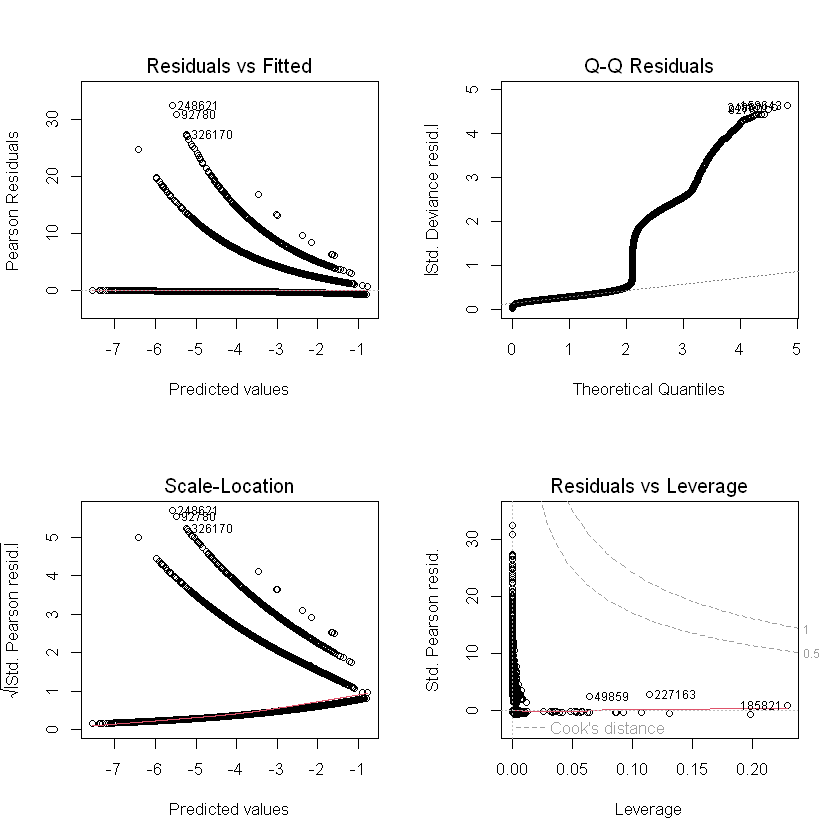

In [35]:
par(mfrow=c(2,2), bg="white")
plot(frequence)
par(mfrow=c(1,1), bg="white")

#### Residuals vs Fitted
La courbe formée par les résidus indique une **hétéroscédasticité** : la variance des résidus varie selon les valeurs ajustées.  
Les points ne sont pas distribués aléatoirement autour de zéro, ce qui montre que le modèle de Poisson **ne capture pas parfaitement la relation entre les variables explicatives et la fréquence des sinistres**.  
Cela confirme la **sous-dispersion** observée précédemment (variance plus faible que la moyenne).

---

#### Q-Q Residuals
Les points s’écartent nettement de la diagonale théorique, en particulier aux extrémités.  
Cela indique que les **résidus ne suivent pas la distribution de Poisson attendue**, notamment pour les valeurs extrêmes.  
Le modèle présente donc un **mauvais ajustement** pour certaines observations atypiques.

---

#### Scale-Location
La tendance visible dans la dispersion des résidus standardisés montre que la **variance n’est pas constante**.  
Les résidus augmentent puis diminuent selon les valeurs ajustées, ce qui confirme une **mauvaise homogénéité de la variance**.  
Le modèle pourrait être amélioré par une transformation ou par un modèle plus flexible.

---

#### Residuals vs Leverage
Quelques points présentent un **fort leverage** et des **résidus élevés**, indiquant qu’ils exercent une **influence importante** sur le modèle.  
Ces observations influentes peuvent correspondre à des **cas de sinistres atypiques ou extrêmes**.  
Elles devraient être examinées individuellement pour vérifier leur validité.


## Modèle de Poisson inflationné à 0 (ZIP)

In [38]:
frequence_zip <- zeroinfl(
  num_claims ~ exterior_cladding + residence_stability_group + deductible + 
    region + alarm_system + hydrant_proximity + fire_station_proximity + 
    heating_type + fidelity_cat + insured_employment + multi_product_discount + 
    smoker + auxiliary_heating + etat_toit + credit_score_level + past_claims + 
    group_age_oldest_insured + marital_status + house_type + water_body_proximity + 
    skylight_presence + room_rental + commercial_activities
  | region + past_claims, 
  data = home,
  dist = "poisson",
  offset = log(earned_exposure)
)

In [37]:
summary(frequence_zip)

Warning message in sqrt(diag(object$vcov)):
"Production de NaN"



Call:
zeroinfl(formula = num_claims ~ exterior_cladding + residence_stability_group + 
    deductible + region + alarm_system + hydrant_proximity + fire_station_proximity + 
    heating_type + fidelity_cat + insured_employment + multi_product_discount + 
    smoker + auxiliary_heating + etat_toit + credit_score_level + past_claims + 
    group_age_oldest_insured + marital_status + house_type + water_body_proximity + 
    skylight_presence + room_rental + commercial_activities | region + 
    fidelity_cat + insured_employment + credit_score_level + past_claims, 
    data = home, offset = log(earned_exposure), dist = "poisson")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.6965 -0.2114 -0.1668 -0.1297 31.1930 

Count model coefficients (poisson with log link):
                                            Estimate Std. Error z value
(Intercept)                                -1.632446   0.738558  -2.210
exterior_claddingVinyl                      0.265076   0.053189   4.

Le message d’avertissement "Production de NaN" indique que certaines variables de la partie zéro-inflation du modèle (logit) ne peuvent pas être estimées correctement.Cela arrive souvent lorsqu’il y a :
- des variables trop rares (ex. certaines régions ou niveaux de past_claims),
- de la colinéarité entre les prédicteurs,
- ou une quasi-séparation entre les observations avec et sans sinistre.

Concrètement, cela veut dire que le modèle n’arrive pas à calculer l’écart-type(d’où les NaN et les erreurs standards énormes pour certaines modalités). En d’autres mots, il est surparamétré par rapport aux données disponibles.

In [55]:
# Tentative de correction 
home$past_claims2plus <- factor(ifelse(home$past_claims %in% c(2, 3), ">=2", as.character(home$past_claims)))

frequence_zip <- zeroinfl(
  num_claims ~ exterior_cladding + residence_stability_group + deductible + 
    region + alarm_system + hydrant_proximity + fire_station_proximity + 
    heating_type + fidelity_cat + insured_employment + multi_product_discount + 
    smoker + auxiliary_heating + etat_toit + credit_score_level + past_claims2plus + 
    group_age_oldest_insured + marital_status + house_type + water_body_proximity + 
    skylight_presence + room_rental + commercial_activities
  | region + past_claims2plus + fidelity_cat + insured_employment + credit_score_level, 
  data = home,
  dist = "poisson",
  offset = log(earned_exposure)
)


In [56]:
summary(frequence_zip)


Call:
zeroinfl(formula = num_claims ~ exterior_cladding + residence_stability_group + 
    deductible + region + alarm_system + hydrant_proximity + fire_station_proximity + 
    heating_type + fidelity_cat + insured_employment + multi_product_discount + 
    smoker + auxiliary_heating + etat_toit + credit_score_level + past_claims2plus + 
    group_age_oldest_insured + marital_status + house_type + water_body_proximity + 
    skylight_presence + room_rental + commercial_activities | region + 
    past_claims2plus + fidelity_cat + insured_employment + credit_score_level, 
    data = home, offset = log(earned_exposure), dist = "poisson")

Pearson residuals:
    Min      1Q  Median      3Q     Max 
-0.7107 -0.2115 -0.1669 -0.1298 31.2799 

Count model coefficients (poisson with log link):
                                            Estimate Std. Error z value
(Intercept)                                -1.439949   0.739464  -1.947
exterior_claddingVinyl                      0.265853   0.0

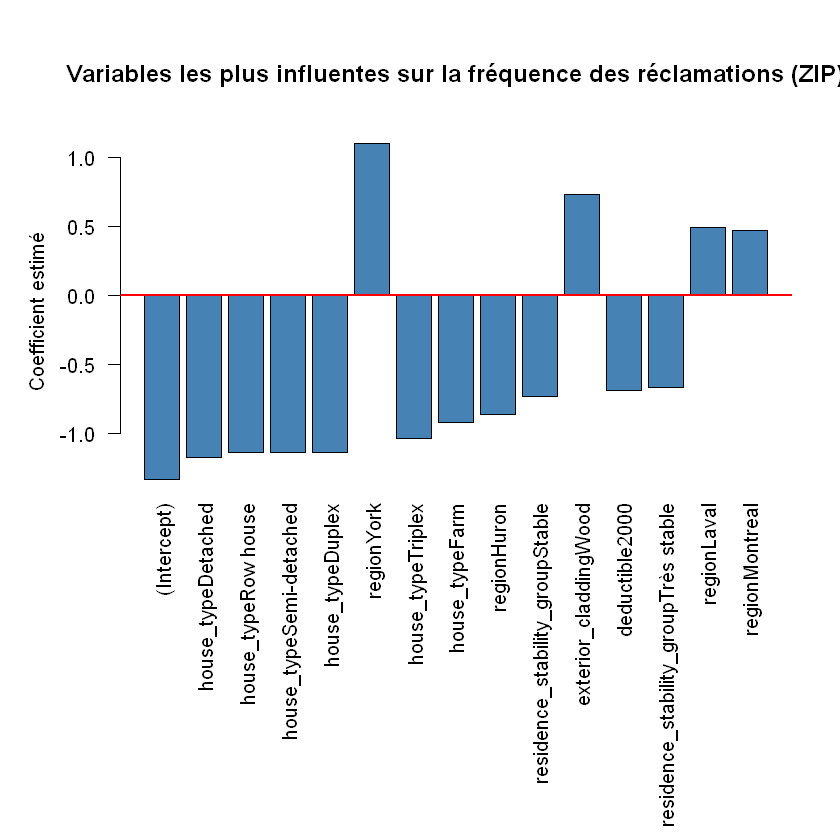

In [57]:
coefs_count <- coefs$count

# Trier les coefficients selon leur valeur absolue (importance)
coefs_sorted <- coefs_count[order(abs(coefs_count[, "Estimate"]), decreasing = TRUE), ]

# Sélectionner les 15 variables les plus influentes
top_vars <- head(coefs_sorted, 15)

# Créer un graphique en barres
par(bg = "white", mar = c(15, 5, 6, 2))  
barplot(top_vars[, "Estimate"],
        names.arg = rownames(top_vars),
        las = 2,                
        col = "steelblue",      
        main = "Variables les plus influentes sur la fréquence des réclamations (ZIP)",
        ylab = "Coefficient estimé")
abline(h = 0, col = "red", lwd = 2)

### Comparaison des 2 modèles 

#### AIC 

In [58]:
AIC(frequence, frequence_zip)

,df,AIC
,<dbl>,<dbl>
frequence,65,105632.4
frequence_zip,91,105558.9


La comparaison des valeurs d’AIC entre les deux modèles montre que le modèle de Poisson simple présente un AIC de **105 632,4**, tandis que le modèle de Poisson à inflation de zéros (ZIP) affiche un AIC légèrement inférieur, soit **105 558,9**. Comme une valeur d’AIC plus faible indique un meilleur compromis entre la qualité d’ajustement et la complexité du modèle, le ZIP semble offrir une amélioration marginale par rapport au modèle de Poisson. Toutefois, la différence d’environ **74 points** demeure faible, ce qui signifie que le modèle ZIP n’apporte pas un gain significatif en performance. En d’autres termes, bien que le modèle à inflation de zéros capte un peu mieux la présence d’excès de zéros, la complexité supplémentaire qu’il introduit n’est pas pleinement justifiée. Ainsi, le modèle de Poisson simple reste globalement suffisant et plus parcimonieux pour expliquer la fréquence des sinistres dans ce cas.

### Test de Vuong

In [59]:
vuong(frequence, frequence_zip)

Vuong Non-Nested Hypothesis Test-Statistic: 
(test-statistic is asymptotically distributed N(0,1) under the
 null that the models are indistinguishible)
-------------------------------------------------------------
              Vuong z-statistic             H_A    p-value
Raw                   -5.047483 model2 > model1 2.2383e-07
AIC-corrected         -2.957400 model2 > model1  0.0015512
BIC-corrected          8.287986 model1 > model2 < 2.22e-16


Le **test de Vuong** permet de comparer deux modèles non emboîtés afin de déterminer lequel décrit le mieux les données.  
Dans notre cas, il oppose le modèle de **Poisson simple** au modèle de **Poisson à inflation de zéros (ZIP)**.

Les résultats montrent un **z-statistic brut de -5,05** avec une **p-value = 2,23e-07**, indiquant que le modèle ZIP s’ajuste significativement mieux que le modèle de Poisson.  
Après **correction AIC**, le résultat reste significatif (**z = -2,96 ; p = 0,0016**), ce qui confirme la supériorité du ZIP pour modéliser les données avec excès de zéros.

Cependant, la **correction BIC** (z = 8,29 ; p < 2,22e-16) favorise le modèle de Poisson, car ce critère pénalise davantage les modèles complexes.  

En conclusion, le modèle ZIP offre un meilleur ajustement selon les critères **brut** et **AIC**, mais au prix d’une
complexité plus élevée. Le modèle de Poisson évite la complexité inutile, tandis que le ZIP est plus adapté si l’on souhaite mieux représenter l’excès de zéros observé dans les données.

On utilisera donc le modèle de Poisson pour la suite.

## Analyse des résultats du modèle de fréquence par variables 

In [70]:
home$predicted_freq <- predict(frequence, type="response")

In [73]:
# 1. Prédictions et écarts-types
pred <- predict(frequence, type = "link", se.fit = TRUE)
home$mu_hat <- exp(pred$fit)
home$se_mu  <- home$mu_hat * pred$se.fit

# 2. Fonction pour calculer les statistiques par variable catégorielle
build_data <- function(varname) {
  var <- home[[varname]]
  if (!is.factor(var)) var <- factor(var)
  
  exp_grp <- tapply(home$earned_exposure, var, sum, na.rm = TRUE)
  claims_grp <- tapply(home$num_claims, var, sum, na.rm = TRUE)
  freq_obs <- claims_grp / exp_grp
  
  freq_glm <- sapply(split(data.frame(mu_hat = home$mu_hat, w = home$earned_exposure), var), 
                     function(z) sum(z$mu_hat * z$w) / sum(z$w))
  
  se_grp <- sapply(split(data.frame(se_mu = home$se_mu, w = home$earned_exposure), var),
                   function(z) sqrt(sum((z$w^2) * (z$se_mu^2)) / (sum(z$w)^2)))
  
  lower <- pmax(0, freq_glm - 2 * se_grp)
  upper <- freq_glm + 2 * se_grp
  
  data.frame(
    Variable = varname,
    Modalite = names(exp_grp),
    Exposure = as.numeric(exp_grp),
    Claims = as.numeric(claims_grp),
    # On affiche les fréquences par 100 habitations
    Freq_obs = as.numeric(freq_obs) * 100,
    Freq_glm = as.numeric(freq_glm) * 100,
    Lower = as.numeric(lower) * 100,
    Upper = as.numeric(upper) * 100
  )
}

In [74]:
build_data("deductible")

Variable,Modalite,Exposure,Claims,Freq_obs,Freq_glm,Lower,Upper
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
deductible,250,47829.55,2582,5.398336,5.155508,5.151215,5.159801
deductible,500,126720.52,5366,4.234515,4.040744,4.038735,4.042753
deductible,1000,79780.22,3187,3.994725,3.815914,3.813602,3.818225
deductible,2000,63257.19,1715,2.711154,2.590396,2.588560,2.592231


In [81]:
## 1) Prédictions sur l’échelle naturelle 
home$mu_pred_year <- predict(frequence, type = "response")  # fréquence prédite (Poisson)

## 2) Fonction d’agrégation 
build_year_table <- function(varname) {
  v <- home[[varname]]
  if (!is.factor(v)) v <- factor(v)
  yr <- home$client_start_year

  # Somme d'exposition
  EXP <- tapply(home$earned_exposure, list(v, yr), sum, na.rm = TRUE)

  # Somme pondérée des prédictions
  NUM <- tapply(home$mu_pred_year * home$earned_exposure, list(v, yr), sum, na.rm = TRUE)

  # Moyenne pondérée (fréquence prédite)
  FREQ_PRED <- NUM / EXP * 100
  FREQ_PRED[is.nan(FREQ_PRED)] <- NA

  # Conversion en data.frame
  df_exp  <- as.data.frame(as.table(EXP), stringsAsFactors = FALSE)
  df_freq <- as.data.frame(as.table(FREQ_PRED), stringsAsFactors = FALSE)
  names(df_exp)  <- c("Modalite", "client_start_year", "Exposure")
  names(df_freq) <- c("Modalite", "client_start_year", "Freq_pred")

  # Fusion et réorganisation
  out <- merge(df_exp, df_freq, by = c("Modalite","client_start_year"), all = TRUE)
  out$Variable <- varname
  out <- out[order(out$client_start_year, out$Modalite),
             c("Variable","Modalite","client_start_year","Exposure","Freq_pred")]
  rownames(out) <- NULL
  out
}


In [82]:
build_year_table("deductible")

Variable,Modalite,client_start_year,Exposure,Freq_pred
<chr>,<chr>,<chr>,<dbl>,<dbl>
deductible,1000,2009,1302.6343,3.379297
deductible,2000,2009,1021.0988,2.236497
deductible,250,2009,791.5925,4.671717
deductible,500,2009,2013.6180,3.499049
deductible,1000,2010,2624.7817,3.235848
deductible,2000,2010,2120.2294,2.267521
deductible,250,2010,1572.5148,4.468549
deductible,500,2010,4188.1561,3.528850
deductible,1000,2011,4081.5381,3.308259


In [85]:
## 1) Prédiction de la fréquence sur l’échantillon de validation
home$mu_valid <- predict(frequence, newdata = home, type = "response")

## 2) Création de classes de fréquence prédite 
n_bins <- 30
brks <- pretty(range(home$mu_valid, na.rm = TRUE), n = n_bins)
bin <- cut(home$mu_valid, breaks = brks, include.lowest = TRUE, right = TRUE)

## 3) Agrégation par classe
expo  <- tapply(home$earned_exposure, bin, sum, na.rm = TRUE)
claims <- tapply(home$num_claims, bin, sum, na.rm = TRUE)
exp_pred_num <- tapply(home$mu_valid * home$earned_exposure,
                       bin, sum, na.rm = TRUE)

## Fréquence prédite moyenne (pondérée par l'exposition)
freq_pred <- exp_pred_num / expo
## Fréquence observée (historique)
freq_obs  <- claims / expo

## 4) Infos sur les bornes des classes (pour l’axe des x)
bin_lower <- brks[-length(brks)]
bin_upper <- brks[-1]
bin_mid   <- (bin_lower + bin_upper) / 2

## On garde uniquement les classes où il y a de l'exposition
idx <- !is.na(expo) & expo > 0

calib_table <- data.frame(
  Bin_ID        = seq_along(expo)[idx],
  Bin_Lower     = bin_lower[idx],
  Bin_Upper     = bin_upper[idx],
  Bin_Mid       = bin_mid[idx],
  Exposure      = as.numeric(expo[idx]),
  Claims        = as.numeric(claims[idx]),
  Freq_Observed = as.numeric(freq_obs[idx]) * 100,   
  Freq_Predicted= as.numeric(freq_pred[idx] * 100)   
)




In [86]:
calib_table

Bin_ID,Bin_Lower,Bin_Upper,Bin_Mid,Exposure,Claims,Freq_Observed,Freq_Predicted
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.00,0.02,0.01,7.942071e+04,1405,1.769060,1.427588
2,0.02,0.04,0.03,1.245807e+05,3732,2.995648,2.902517
3,0.04,0.06,0.05,6.195724e+04,3075,4.963101,4.871752
4,0.06,0.08,0.07,2.795833e+04,2010,7.189269,6.864637
5,0.08,0.10,0.09,1.218207e+04,1079,8.857278,8.866226
6,0.10,0.12,0.11,5.697968e+03,646,11.337374,10.882008
7,0.12,0.14,0.13,2.796770e+03,358,12.800481,12.859711
8,0.14,0.16,0.15,1.373836e+03,205,14.921725,14.885858
9,0.16,0.18,0.17,7.207949e+02,131,18.174379,16.910207


In [90]:
# Liste des variables 
vars <- c(
  "exterior_cladding",
  "residence_stability_group",
  "deductible",
  "region",
  "alarm_system",
  "hydrant_proximity",
  "fire_station_proximity",
  "heating_type",
  "fidelity_cat",
  "insured_employment",
  "multi_product_discount",
  "smoker",
  "auxiliary_heating",
  "etat_toit",
  "credit_score_level",
  "past_claims2plus",
  "group_age_oldest_insured",
  "marital_status",
  "house_type",
  "water_body_proximity",
  "skylight_presence",
  "room_rental",
  "commercial_activities"
)

# Création du classeur Excel
wb <- createWorkbook()

for (v in vars) {
  # Construire les deux tableaux pour la variable v
  tab_year <- build_year_table(v)  # par modalité ET client_start_year
  tab_marg <- build_data(v)        # tableau global par modalité 

  # Nom de feuille 
  sheet_name <- substr(v, 1, 31)

  # Ajouter la feuille au classeur
  addWorksheet(wb, sheet_name)

  # Écrire le tableau "par année"
  writeData(wb, sheet = sheet_name,
            x = paste("Variable :", v, "- Tableau par année"),
            startRow = 1, startCol = 1)

  writeData(wb, sheet = sheet_name,
            x = tab_year,
            startRow = 3, startCol = 1)

  # Écrire le tableau "global" en dessous
  start_row_marg <- nrow(tab_year) + 5

  writeData(wb, sheet = sheet_name,
            x = paste("Variable :", v, "- Tableau global (toutes années)"),
            startRow = start_row_marg, startCol = 1)

  writeData(wb, sheet = sheet_name,
            x = tab_marg,
            startRow = start_row_marg + 2, startCol = 1)
}

# Sauvegarder le classeur
saveWorkbook(wb, file = "Analyse_frequence.xlsx", overwrite = TRUE)